# Libs


In [ ]:
import gdown
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
import scipy.stats as stats
import seaborn as sns
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
from math import sqrt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="darkgrid", palette="muted")


In [ ]:
# pib 

url = 'drive url'
output = 'q_data.csv'
gdown.download(url, output, quiet=False)



Downloading...
From: https://drive.google.com/uc?id=1-jIhgKchXjhlB6oWZ_M-ut0wJnck0ZCr
To: /content/q_data.csv
100%|██████████| 161k/161k [00:00<00:00, 20.1MB/s]


'q_data.csv'

In [ ]:
quarterly_df = pd.read_csv('q_data.csv')
quarterly_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 656 entries, 0 to 655
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   municipio               656 non-null    object 
 1   quarter                 656 non-null    object 
 2   pib_mun                 656 non-null    float64
 3   total_pixeles_median    656 non-null    float64
 4   suma_rad_trend_sum      656 non-null    float64
 5   suma_rad_trend_mean     656 non-null    float64
 6   suma_rad_trend_std      656 non-null    float64
 7   suma_rad_trend_median   656 non-null    float64
 8   media_rad_trend_mean    656 non-null    float64
 9   std_rad_trend_mean      656 non-null    float64
 10  max_rad_trend_max       656 non-null    float64
 11  min_rad_trend_min       656 non-null    float64
 12  p25_rad_trend_mean      656 non-null    float64
 13  mediana_rad_trend_mean  656 non-null    float64
 14  p75_rad_trend_mean      656 non-null    fl

In [ ]:
def preprocess(dataframe, log = True,  encode = True, n_lags= 2, ):
  df = dataframe.copy()

  df['quarter'] = pd.PeriodIndex(df['quarter'], freq='Q')
  df['fecha'] = df['quarter'].dt.to_timestamp(how='end')
  df['year'] = df['fecha'].dt.year

  log_cols =  ['pib_mun', 'suma_rad_trend_sum', 'suma_rad_trend_mean', 'suma_rad_trend_std',
       'suma_rad_trend_median', 'media_rad_trend_mean', 'std_rad_trend_mean',
       'max_rad_trend_max', 'min_rad_trend_min', 'p25_rad_trend_mean',
       'mediana_rad_trend_mean', 'p75_rad_trend_mean']

  if log:
    df[log_cols] = df[log_cols].replace(0, 1e-5)
    df[log_cols]= df[log_cols].apply(np.log)

  df = df.sort_values(['municipio', 'quarter'])

  col = 'suma_rad_trend_median'

  for lag in range(1, n_lags + 1):
    df[f'{col}_lag{lag}'] = df.groupby('municipio')[col].shift(lag)

  if encode:
    df = pd.get_dummies(
        df,
        columns= ['municipio'],
        drop_first=False,
        dtype=int
    )

    df = df.dropna()

  return df

In [ ]:
df_processed = preprocess(quarterly_df)

In [ ]:
df_processed.columns

Index(['quarter', 'pib_mun', 'total_pixeles_median', 'suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean', 'fecha', 'year', 'suma_rad_trend_median_lag1',
       'suma_rad_trend_median_lag2', 'municipio_alvaro obregon',
       'municipio_azcapotzalco', 'municipio_benito juarez',
       'municipio_coyoacan', 'municipio_cuajimalpa de morelos',
       'municipio_cuauhtemoc', 'municipio_gustavo a. madero',
       'municipio_iztacalco', 'municipio_iztapalapa',
       'municipio_la magdalena contreras', 'municipio_miguel hidalgo',
       'municipio_milpa alta', 'municipio_tlahuac', 'municipio_tlalpan',
       'municipio_venustiano carranza', 'municipio_xochimilco'],
      dtype='object')

# Initial RF

In [ ]:
# Kfold 

features = ['total_pixeles_median', 'suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean', 'year', 'municipio_alvaro obregon',
       'municipio_azcapotzalco', 'municipio_benito juarez',
       'municipio_coyoacan', 'municipio_cuajimalpa de morelos',
       'municipio_cuauhtemoc', 'municipio_gustavo a. madero',
       'municipio_iztacalco', 'municipio_iztapalapa',
       'municipio_la magdalena contreras', 'municipio_miguel hidalgo',
       'municipio_milpa alta', 'municipio_tlahuac', 'municipio_tlalpan',
       'municipio_venustiano carranza', 'municipio_xochimilco']


X = df_processed[features]
y = df_processed['pib_mun']

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features, index=X.index)

y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

# 2. Entrenar OLS en datos escalados
X_ols = sm.add_constant(X_scaled)
ols_model = sm.OLS(y_scaled, X_ols).fit()
y_hat_ols = ols_model.predict(X_ols)
residuals_ols = y_scaled - y_hat_ols

# 3. Entrenar RF en los residuales (SIN la constante)
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    random_state=42
)
rf.fit(X_scaled, residuals_ols)

#pred

# ols
y_pred_ols_scaled = y_hat_ols

# rf on resids
y_pred_rf_scaled = rf.predict(X_scaled)

# pred hyb
y_pred_hybrid_scaled = y_pred_ols_scaled + y_pred_rf_scaled

# Desescalar predicción
y_pred_hybrid = scaler_y.inverse_transform(
    y_pred_hybrid_scaled.values.reshape(-1, 1)
).ravel()

# metricas

y_real = np.exp(y)
y_pred_real = np.exp(y_pred_hybrid)

fold_global_metrics = []

mse = mean_squared_error(y_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_real, y_pred_real)

# Convertir de log a escala original

mape = np.mean(np.abs((y_real - y_pred_real) / y_real)) * 100


fold_global_metrics.append({
    'MSE': mse,
    'RMSE': rmse,
    'MAE': mae,
    'MAPE': mape
})



residuals_hybrid = y - y_pred_hybrid
print(fold_global_metrics)


[{'MSE': 1662738.4304764832, 'RMSE': np.float64(1289.4721518809483), 'MAE': 836.9876465269216, 'MAPE': np.float64(0.49335596527032055)}]


# Elasticidad

In [ ]:
def get_elasticity(x, y_pred, mun, plot=False):
    x = np.array(x)
    y_pred = np.array(y_pred)

    x = np.exp(x)
    y_pred = np.exp(y_pred)

    pct_change_x = (x[1:] - x[:-1]) / x[:-1]
    pct_change_y = (y_pred[1:] - y_pred[:-1]) / y_pred[:-1]

    mask = np.abs(pct_change_x) > 1e-3  # ignorar cercanos a cero
    elasticity = pct_change_y[mask] / pct_change_x[mask]


    elasticity_avg = np.mean(elasticity)

    if plot:
      plt.figure(figsize=(8, 4))
      plt.plot(elasticity, marker='o', alpha=0.7)
      plt.axhline(elasticity_avg, color='red', linestyle='--', label=f'Promedio = {elasticity_avg:.2f}')
      plt.title(f"Elasticidad Predicción-Variable en el tiempo: {mun.capitalize()}")
      plt.xlabel("t")
      plt.ylabel("Elasticidad")
      plt.legend()
      plt.show()

    return elasticity_avg, elasticity



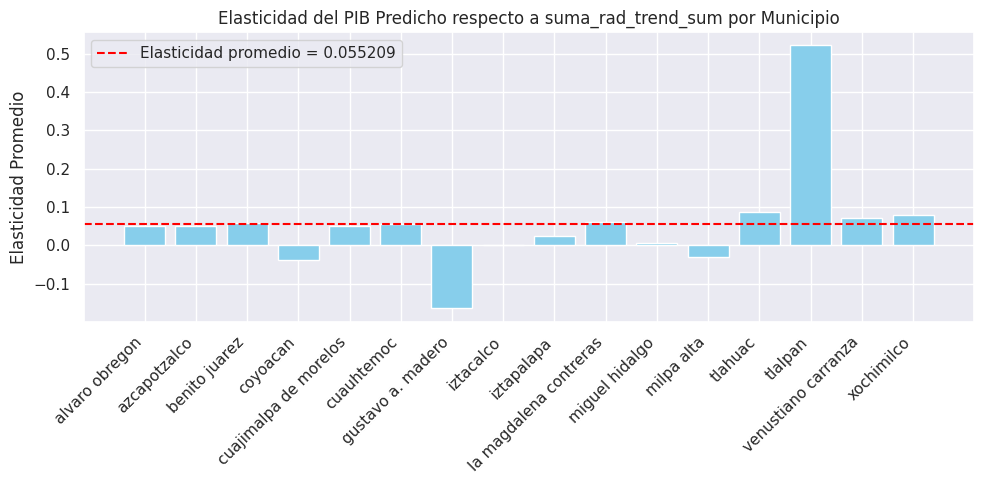

Elasticity - suma_rad_trend_sum
Mean elasticity: 0.055
Std deviation: 0.135
Min: -0.165, Max: 0.522


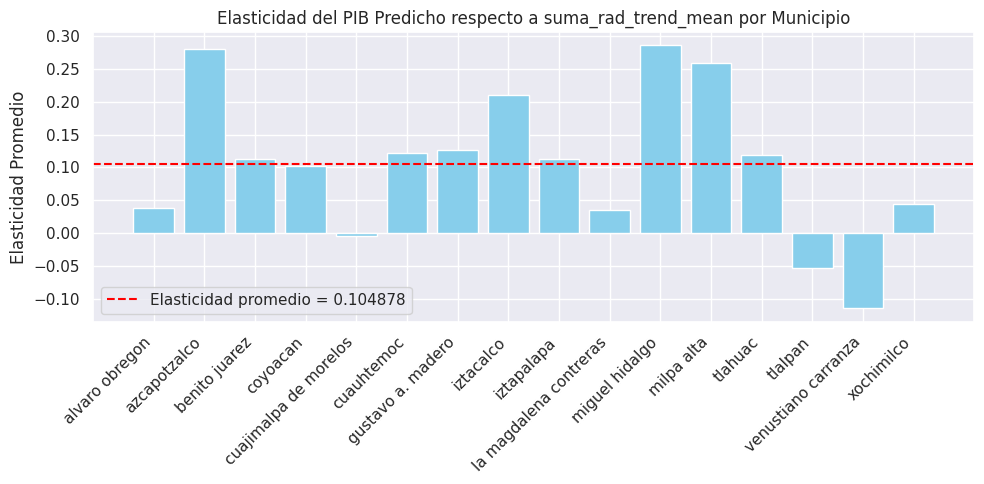

Elasticity - suma_rad_trend_mean
Mean elasticity: 0.105
Std deviation: 0.111
Min: -0.115, Max: 0.286


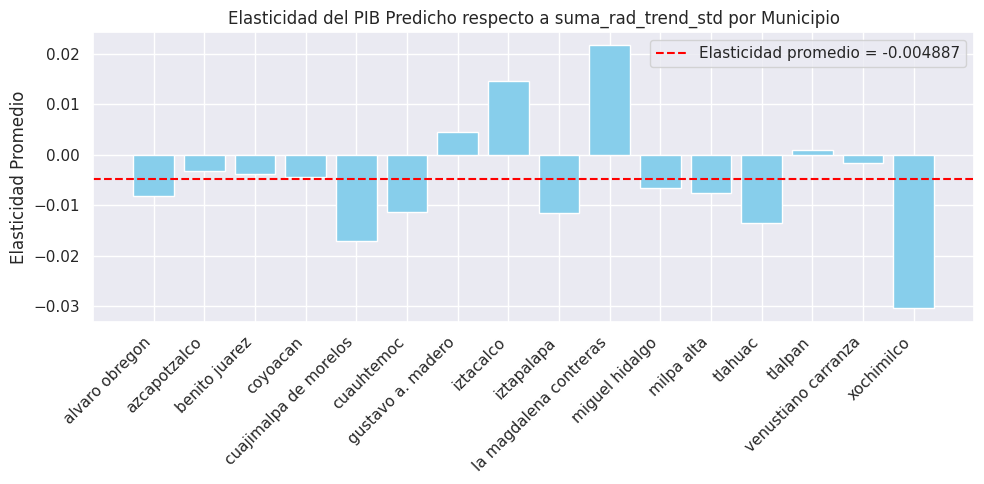

Elasticity - suma_rad_trend_std
Mean elasticity: -0.005
Std deviation: 0.012
Min: -0.030, Max: 0.022


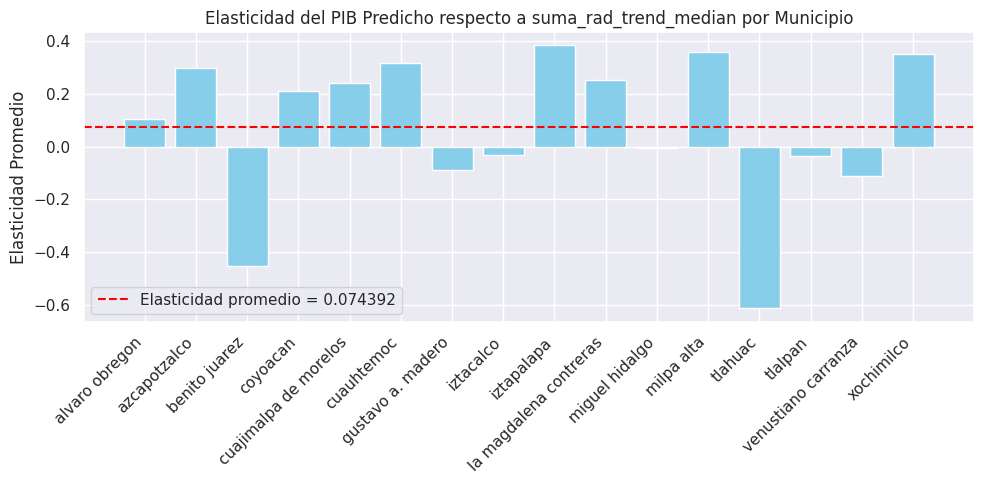

Elasticity - suma_rad_trend_median
Mean elasticity: 0.074
Std deviation: 0.284
Min: -0.614, Max: 0.385


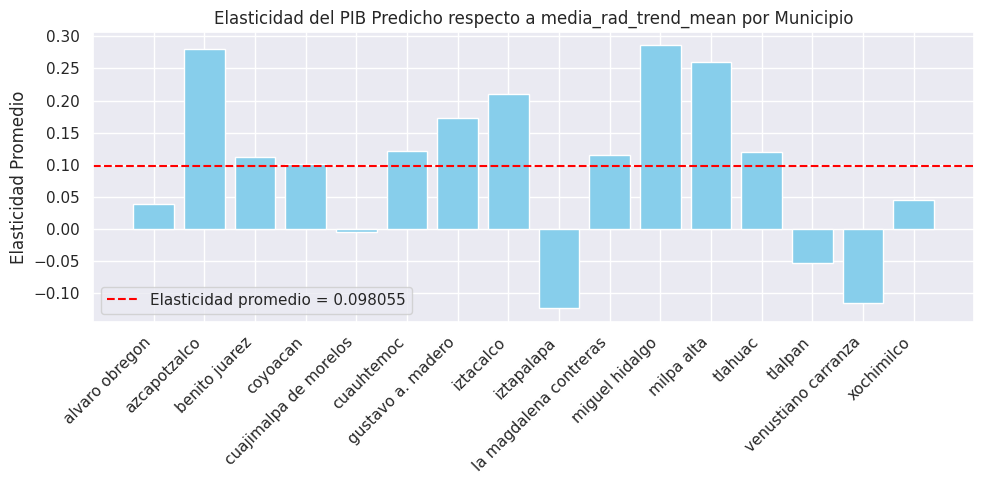

Elasticity - media_rad_trend_mean
Mean elasticity: 0.098
Std deviation: 0.124
Min: -0.123, Max: 0.286


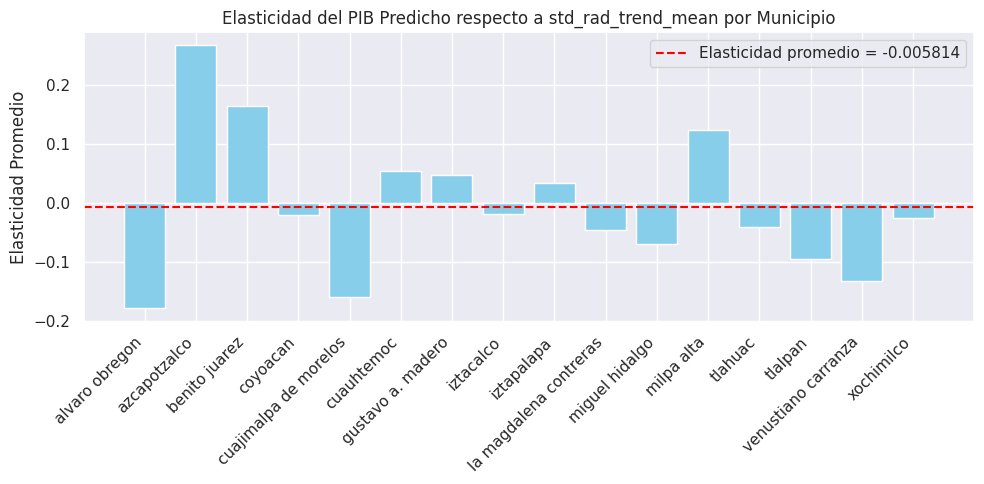

Elasticity - std_rad_trend_mean
Mean elasticity: -0.006
Std deviation: 0.115
Min: -0.178, Max: 0.267


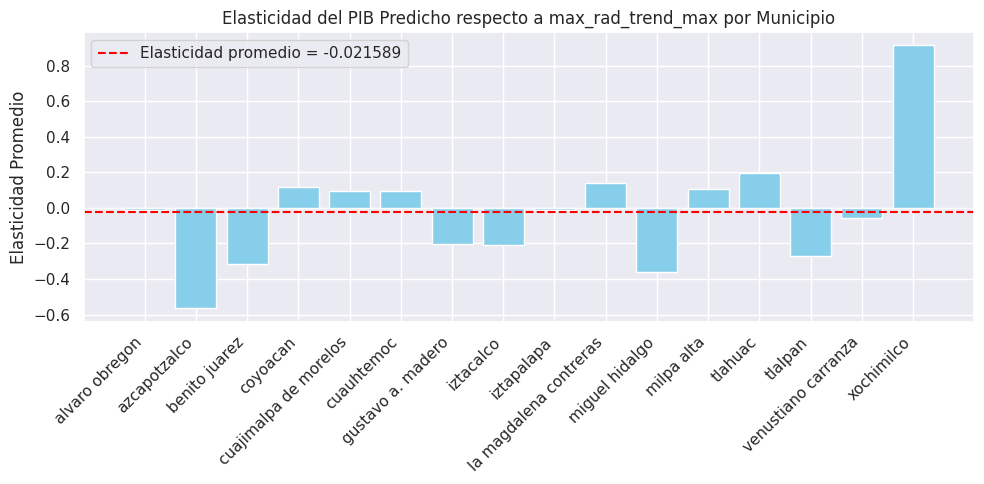

Elasticity - max_rad_trend_max
Mean elasticity: -0.022
Std deviation: 0.320
Min: -0.565, Max: 0.913


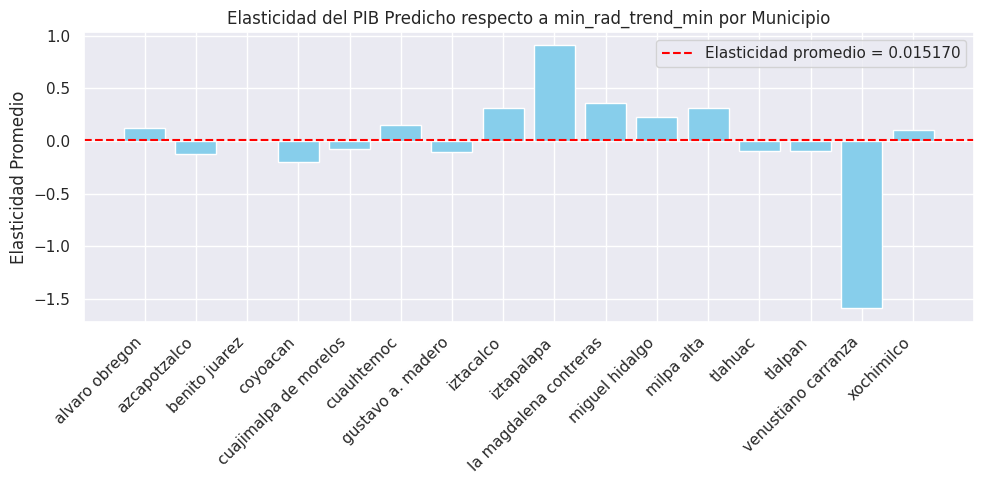

Elasticity - min_rad_trend_min
Mean elasticity: 0.015
Std deviation: 0.491
Min: -1.588, Max: 0.908


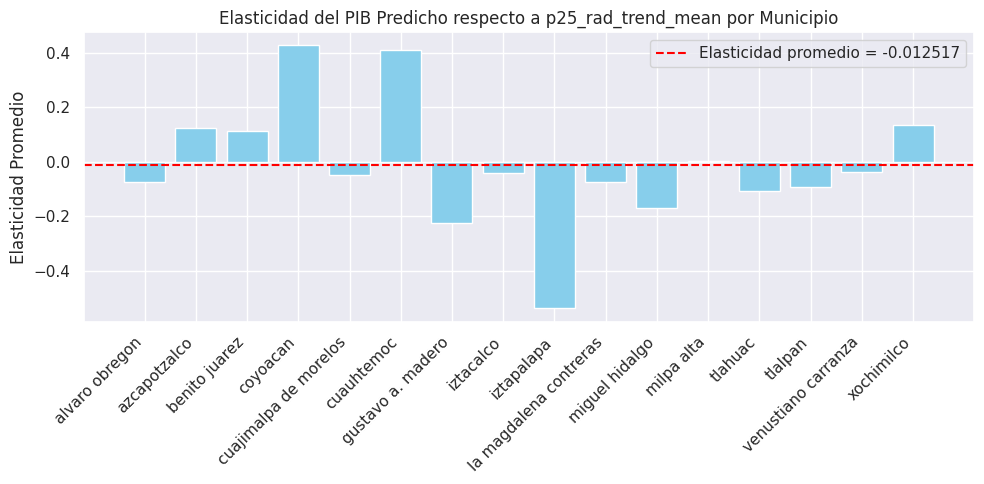

Elasticity - p25_rad_trend_mean
Mean elasticity: -0.013
Std deviation: 0.224
Min: -0.538, Max: 0.426


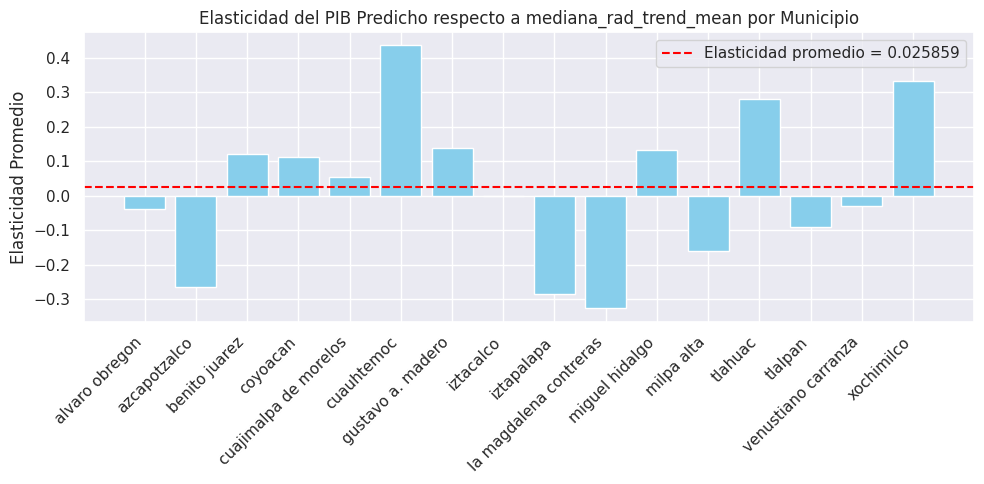

Elasticity - mediana_rad_trend_mean
Mean elasticity: 0.026
Std deviation: 0.213
Min: -0.326, Max: 0.436


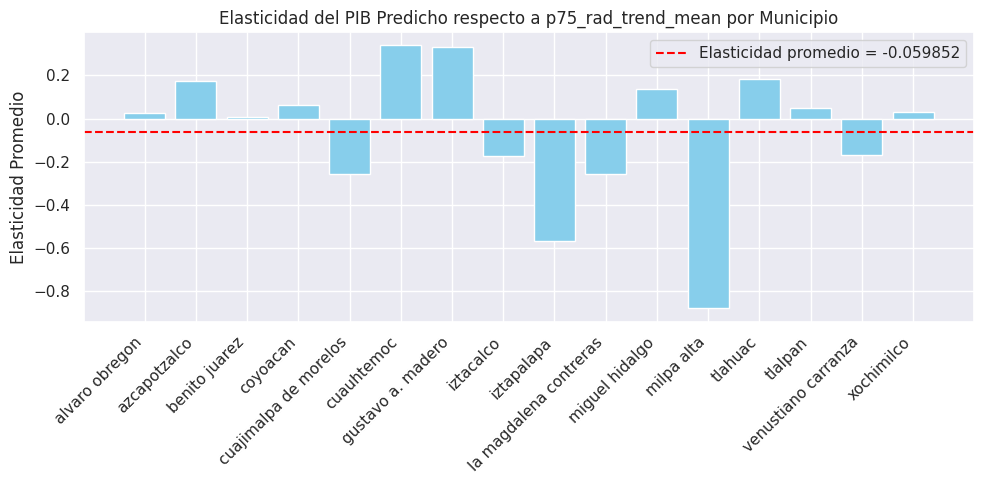

Elasticity - p75_rad_trend_mean
Mean elasticity: -0.060
Std deviation: 0.310
Min: -0.878, Max: 0.339


In [ ]:
elasticity_results = {}

municipios = [
    'alvaro obregon', 'azcapotzalco', 'benito juarez', 'coyoacan',
    'cuajimalpa de morelos', 'cuauhtemoc', 'gustavo a. madero',
    'iztacalco', 'iztapalapa', 'la magdalena contreras', 'miguel hidalgo',
    'milpa alta', 'tlahuac', 'tlalpan', 'venustiano carranza', 'xochimilco'
]

feat_plot = ['suma_rad_trend_sum',
       'suma_rad_trend_mean', 'suma_rad_trend_std', 'suma_rad_trend_median',
       'media_rad_trend_mean', 'std_rad_trend_mean', 'max_rad_trend_max',
       'min_rad_trend_min', 'p25_rad_trend_mean', 'mediana_rad_trend_mean',
       'p75_rad_trend_mean']

y_pred_hybrid_series = pd.Series(y_pred_hybrid, index=df_processed.index)

for feature in feat_plot:
    elasticity_results = {}

    for m in municipios:
        col = f'municipio_{m}'
        df_mun = df_processed[df_processed[col] == 1]



        x_m = df_mun[feature]
        y_pred_m = y_pred_hybrid_series.loc[df_mun.index]

        elasticity_avg, serie_E = get_elasticity(x_m, y_pred_m, m)
        elasticity_results[m] = elasticity_avg

    avg_elasticity = np.mean(list(elasticity_results.values()))

    plt.figure(figsize=(10,5))
    plt.bar(elasticity_results.keys(), elasticity_results.values(), color='skyblue')
    plt.axhline(avg_elasticity, color='red', linestyle='--',
                label=f'Elasticidad promedio = {avg_elasticity:4f}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Elasticidad Promedio')
    plt.title(f'Elasticidad del PIB Predicho respecto a {feature} por Municipio')
    plt.legend()
    plt.tight_layout()
    plt.show()

    values = list(elasticity_results.values())
    print(f'Elasticity - {feature}')
    print(f"Mean elasticity: {np.mean(values):.3f}")
    print(f"Std deviation: {np.std(values):.3f}")
    print(f"Min: {np.min(values):.3f}, Max: {np.max(values):.3f}")





In [ ]:
from statsmodels.tsa.stattools import adfuller

def prueba_adf(series, name="Series"):
    result = adfuller(series.dropna())
    print(f"\n Prueba ADF {name}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4e}")
    print(f"Valores críticos:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    if result[1] < 0.05:
        print("Serie estacionaria")
    else:
        print("Serie no es estacionaria")


In [ ]:
# Prueba ADF y elasticidad por  mun
elasticity_results_mun = {}

municipios = [
    'alvaro obregon', 'azcapotzalco', 'benito juarez', 'coyoacan',
    'cuajimalpa de morelos', 'cuauhtemoc', 'gustavo a. madero',
    'iztacalco', 'iztapalapa', 'la magdalena contreras', 'miguel hidalgo',
    'milpa alta', 'tlahuac', 'tlalpan', 'venustiano carranza', 'xochimilco'
]

feat_plot = ['suma_rad_trend_sum']

y_pred_hybrid_series = pd.Series(y_pred_hybrid, index=df_processed.index)

for feature in feat_plot:
  print(f"=== Feature: {feature}")
  for m in municipios:
    col = f'municipio_{m}'
    df_mun = df_processed[df_processed[col] == 1]

    df_mun = df_mun.sort_values('fecha')

    x_m = df_mun[feature].values
    prod = 0.7037940607
    x_m = x_m*prod
    y_pred_m = y_pred_hybrid_series.loc[df_mun.index].values



    elasticity_avg, serie_E = get_elasticity(x_m, y_pred_m, m)

    prueba_adf(pd.Series(serie_E), f"Elasticidad {m.capitalize()}")
    print(f"Elasticidad {m.capitalize()}: {elasticity_avg}")


    #plt.figure(figsize=(10,5))
    #plt.plot(serie_E)
    #plt.ylabel('Elasticidad')
    #plt.title(f'Elasticidad del PIB Predicho respecto a {feature} - {m.capitalize()}')
    #plt.tight_layout()
    #plt.show()

    #plt.figure(figsize=(10,5))
    #plt.plot(x_m)
    #plt.plot(y_pred_m)
    #plt.title(f'{feature} - {m.capitalize()}')
    #plt.show()

    elasticity_results_mun[m] = elasticity_avg


=== Feature: suma_rad_trend_sum

 Prueba ADF Elasticidad Alvaro obregon
ADF Statistic: -2.9698
p-value: 3.7817e-02
Valores críticos:
   1%: -3.6267
   5%: -2.9460
   10%: -2.6117
Serie estacionaria
Elasticidad Alvaro obregon: -4.582900382136504

 Prueba ADF Elasticidad Azcapotzalco
ADF Statistic: -5.8715
p-value: 3.2329e-07
Valores críticos:
   1%: -3.6267
   5%: -2.9460
   10%: -2.6117
Serie estacionaria
Elasticidad Azcapotzalco: 1.3125428220191668

 Prueba ADF Elasticidad Benito juarez
ADF Statistic: -5.8362
p-value: 3.8707e-07
Valores críticos:
   1%: -3.6267
   5%: -2.9460
   10%: -2.6117
Serie estacionaria
Elasticidad Benito juarez: 21.186990259823233

 Prueba ADF Elasticidad Coyoacan
ADF Statistic: -6.0153
p-value: 1.5384e-07
Valores críticos:
   1%: -3.6267
   5%: -2.9460
   10%: -2.6117
Serie estacionaria
Elasticidad Coyoacan: -92.73490444893665

 Prueba ADF Elasticidad Cuajimalpa de morelos
ADF Statistic: -7.5757
p-value: 2.7654e-11
Valores críticos:
   1%: -3.6209
   5%: -2.9